# 2B: Crypto Portfolio Risk Calculator (Finance)

# Crypto Portfolio Risk Calculator using Bayesian MCMC

## Objective
Cryptocurrency markets are highly volatile, making risk estimation crucial for portfolio allocation. 
Traditional methods estimate volatility using simple statistics, but they ignore uncertainty in the estimates.

In this project we use **Bayesian inference with Markov Chain Monte Carlo (MCMC)** to estimate the volatility 
of cryptocurrency returns and quantify the uncertainty around those estimates.

## Cryptocurrencies Analyzed
We analyze the following five cryptocurrencies:

- Bitcoin (BTC)
- Ethereum (ETH)
- Cardano (ADA)
- Solana (SOL)
- Chainlink (LINK)

## Workflow
The project follows these steps:

1. Download cryptocurrency price data
2. Compute daily log returns
3. Explore the data visually
4. Estimate volatility using Bayesian MCMC
5. Analyze posterior distributions
6. Compute portfolio risk with uncertainty
7. Interpret the results

This approach provides a **probabilistic estimate of portfolio risk instead of a single point estimate**.

In [1]:
# Numerical computation
import numpy as np

# Data manipulation
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Finance data API
import yfinance as yf

# Bayesian modelling
import pymc as pm

# Bayesian visualization tools
import arviz as az

# Make plots look nicer
sns.set_style("darkgrid")

# Set default figure size
plt.rcParams["figure.figsize"] = (10,6)

/Users/mayankagrawal/anaconda3/envs/satellite_ml/lib/python3.10/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


## Step 1: Download Cryptocurrency Price Data

To estimate volatility we first need historical price data for the cryptocurrencies.

We download the **last 30 days of closing prices** using the `yfinance` API.

The cryptocurrencies analyzed are:

- Bitcoin (BTC)
- Ethereum (ETH)
- Cardano (ADA)
- Solana (SOL)
- Chainlink (LINK)

We focus on **closing prices** because they are commonly used in financial return calculations.

In [2]:
np.random.seed(42)

In [3]:
# Download crypto data safely

coins = ['BTC-USD','ETH-USD','ADA-USD','SOL-USD','LINK-USD']

# download data
prices = yf.download(
    coins,
    period="30d",
    interval="1d",
    group_by='ticker',
    auto_adjust=True,
    threads=False
)

# extract closing prices
prices = pd.DataFrame({
    "BTC": prices["BTC-USD"]["Close"],
    "ETH": prices["ETH-USD"]["Close"],
    "ADA": prices["ADA-USD"]["Close"],
    "SOL": prices["SOL-USD"]["Close"],
    "LINK": prices["LINK-USD"]["Close"]
})

# remove missing values if any
prices = prices.dropna()

prices.head()

[                       0%                       ]

[*******************   40%                       ]  2 of 5 completed

[**********************60%****                   ]  3 of 5 completed

[**********************80%*************          ]  4 of 5 completed

[*********************100%***********************]  5 of 5 completed

[*********************100%***********************]  5 of 5 completed

,BTC,ETH,ADA,SOL,LINK
Date,,,,,
2026-05-14,81051.250000,2280.934814,0.270159,92.148727,10.473087
2026-05-15,79065.679688,2223.328857,0.261488,89.200356,10.066180
2026-05-16,78131.437500,2179.751953,0.255041,86.536484,9.719931
2026-05-17,77429.351562,2127.645264,0.251876,85.172951,9.554132
2026-05-18,76954.171875,2128.516113,0.251354,85.296898,9.592829


In [4]:
prices.isna().sum()

BTC     0
ETH     0
ADA     0
SOL     0
LINK    0
dtype: int64

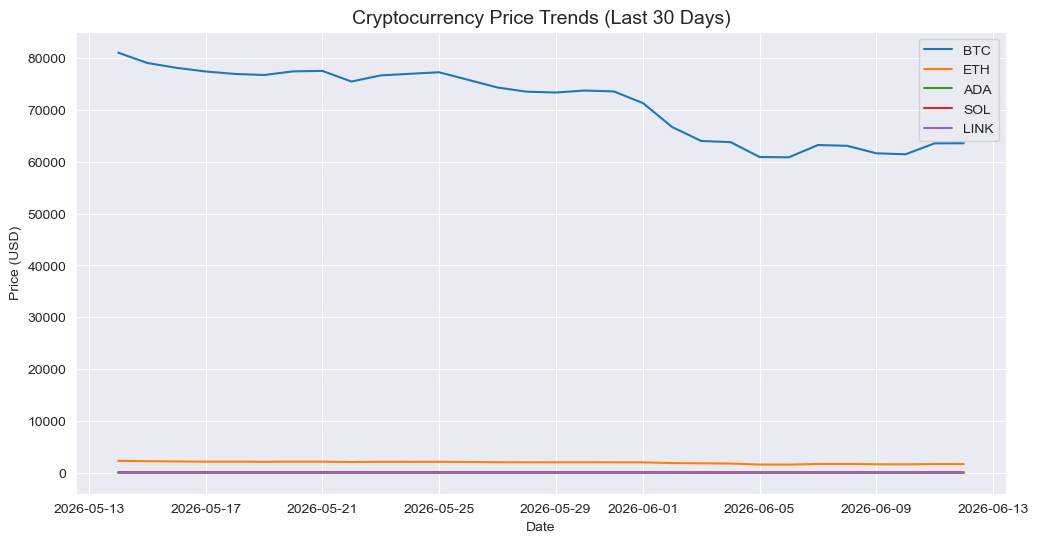

In [5]:
# Plot cryptocurrency price trends

plt.figure(figsize=(12,6))

for coin in prices.columns:
    
    plt.plot(prices.index, prices[coin], label=coin)

plt.title("Cryptocurrency Price Trends (Last 30 Days)", fontsize=14)

plt.xlabel("Date")

plt.ylabel("Price (USD)")

plt.legend()

plt.show()

## Step 2: Compute Daily Log Returns

Financial analysis typically uses **returns instead of raw prices**.

Returns measure the relative change in price from one day to the next.

We compute **log returns**, defined as:

r_t = log(P_t / P_{t-1})

Advantages of log returns:

• Scale invariant  
• Easier statistical modelling  
• Commonly used in quantitative finance  

In [6]:
# Compute daily log returns

log_returns = np.log(prices / prices.shift(1))

# Remove first row (NaN)
log_returns = log_returns.dropna()

log_returns.head()

,BTC,ETH,ADA,SOL,LINK
Date,,,,,
2026-05-15,-0.024803,-0.025580,-0.032622,-0.032519,-0.039628
2026-05-16,-0.011886,-0.019794,-0.024964,-0.030319,-0.035003
2026-05-17,-0.009027,-0.024195,-0.012487,-0.015882,-0.017205
2026-05-18,-0.006156,0.000409,-0.002075,0.001454,0.004042
2026-05-19,-0.002645,-0.008754,-0.012531,-0.012841,-0.015025


In [7]:
log_returns.shape

(29, 5)

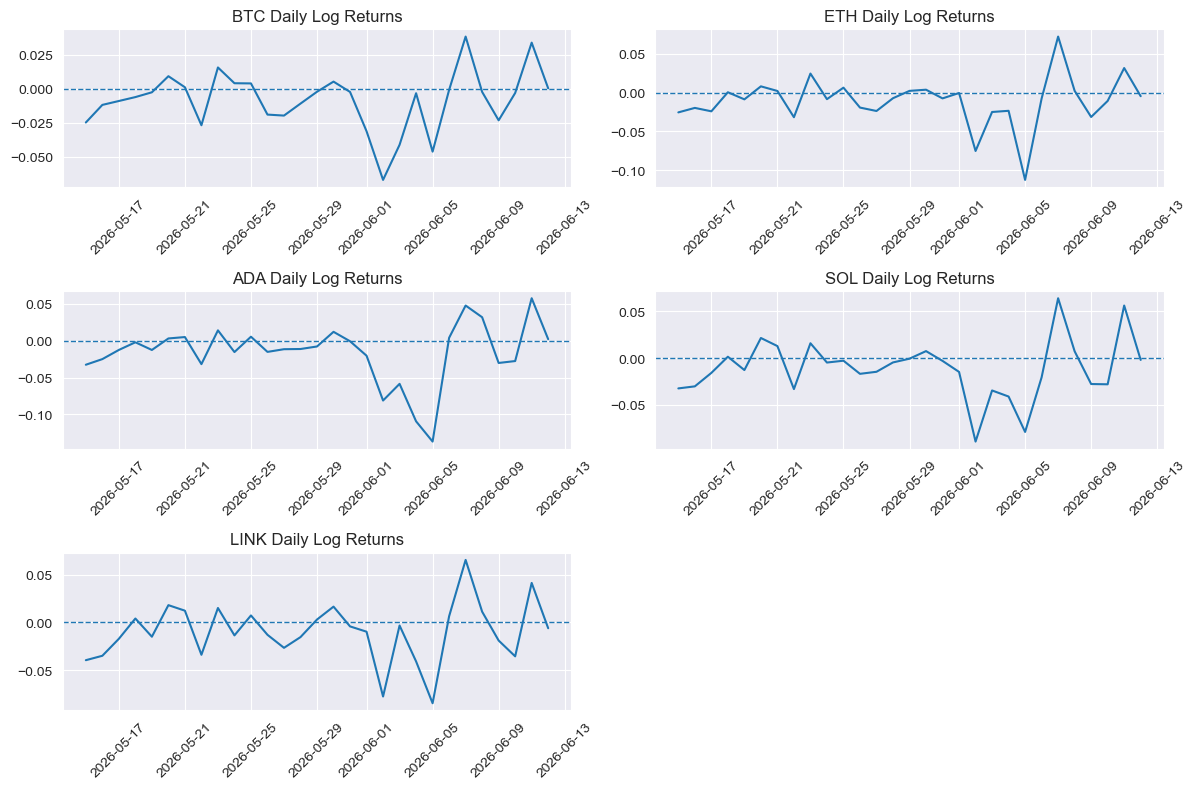

In [8]:
# Plot log returns for each cryptocurrency

fig, axes = plt.subplots(3, 2, figsize=(12,8))

axes = axes.flatten()

for i, coin in enumerate(log_returns.columns):

    axes[i].plot(log_returns.index, log_returns[coin])

    axes[i].axhline(0, linestyle='--', linewidth=1)
    
    axes[i].set_title(f"{coin} Daily Log Returns")
    
    # rotate dates for readability
    axes[i].tick_params(axis='x', rotation=45)

# remove the extra empty subplot
fig.delaxes(axes[-1])

plt.tight_layout()

plt.show()

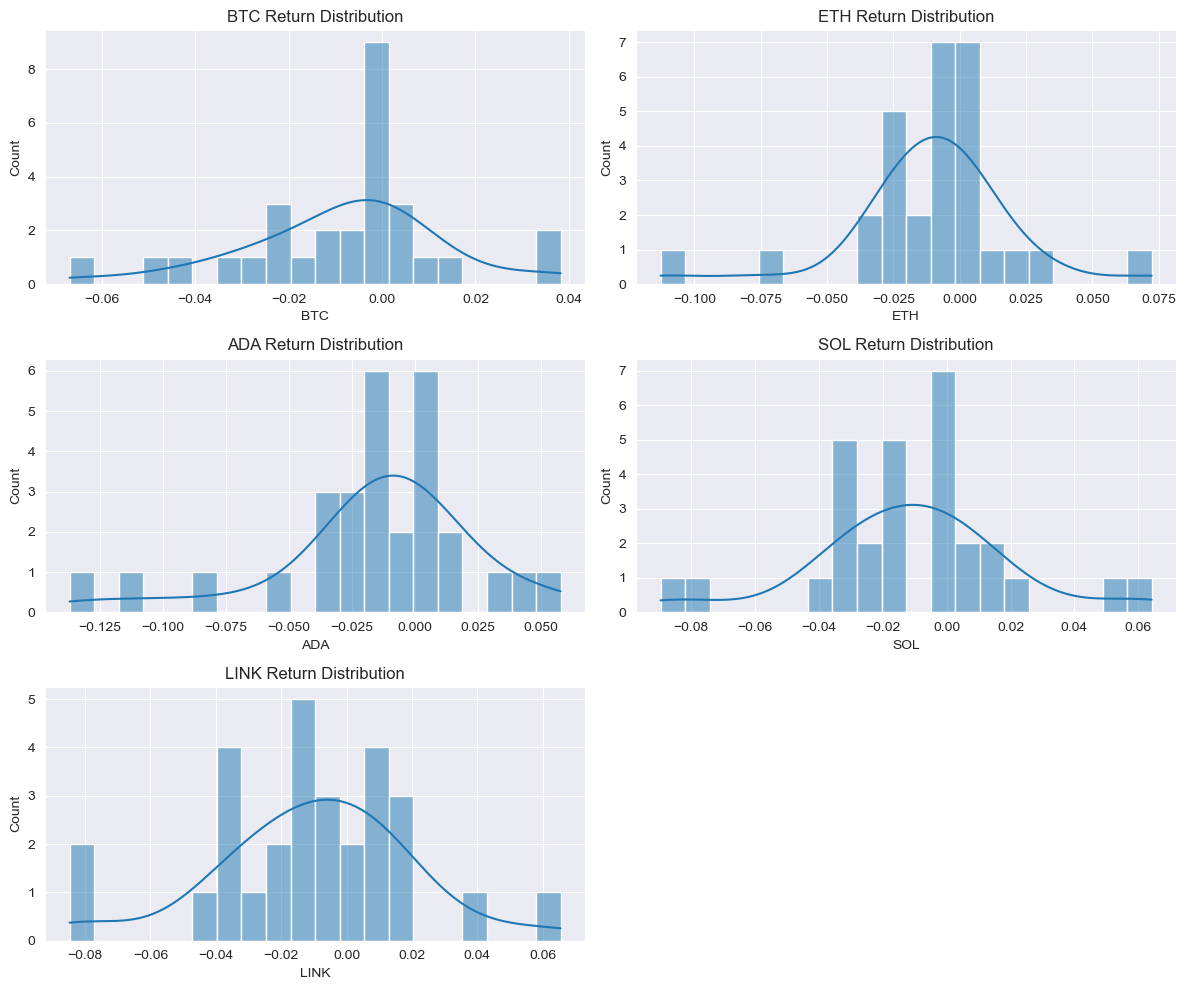

In [9]:
# Distribution of returns

fig, axes = plt.subplots(3, 2, figsize=(12,10))

axes = axes.flatten()

for i, coin in enumerate(log_returns.columns):

    sns.histplot(log_returns[coin], bins=20, kde=True, ax=axes[i])

    axes[i].set_title(f"{coin} Return Distribution")

# remove extra subplot
fig.delaxes(axes[-1])

plt.tight_layout()

plt.show()

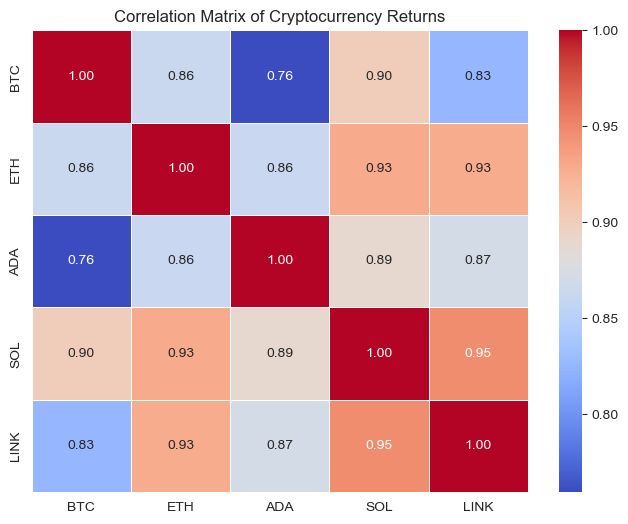

In [10]:
# Correlation heatmap of crypto returns

plt.figure(figsize=(8,6))

sns.heatmap(
    log_returns.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Cryptocurrency Returns")

plt.show()

## Rolling Volatility Analysis

Financial markets exhibit **time-varying volatility**.

To visualize how volatility evolves through time, we compute the **rolling standard deviation of log returns**.

This provides a dynamic estimate of risk for each cryptocurrency.

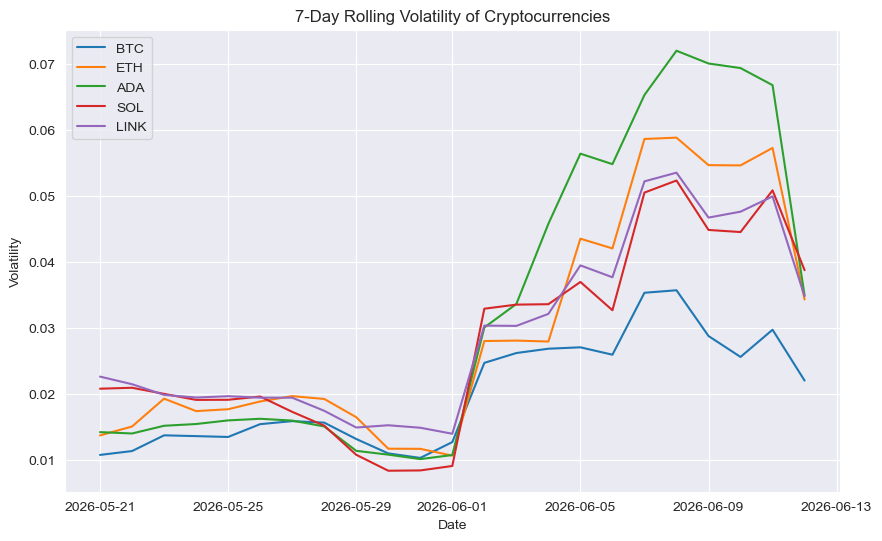

In [11]:
# Rolling volatility calculation

rolling_vol = log_returns.rolling(window=7).std()

plt.figure(figsize=(10,6))

for coin in rolling_vol.columns:
    
    plt.plot(rolling_vol.index, rolling_vol[coin], label=coin)

plt.title("7-Day Rolling Volatility of Cryptocurrencies")

plt.xlabel("Date")

plt.ylabel("Volatility")

plt.legend()

plt.show()

## Step 3: Bayesian Estimation of Volatility

To estimate the risk of each cryptocurrency we model the daily log returns as:

r_t ~ Normal(0, σ²)

where:

σ = volatility of the asset

Instead of estimating a single value for σ, we estimate its **posterior distribution using Bayesian inference**.

We assume a prior:

σ ~ HalfNormal(0.05)

This ensures volatility is positive while allowing reasonable variation.

We use **Markov Chain Monte Carlo (MCMC)** sampling to obtain samples from the posterior distribution.

In [12]:
# Bayesian volatility estimation function

def estimate_volatility(returns):

    with pm.Model() as model:

        # prior for volatility
        sigma = pm.HalfNormal("sigma", sigma=0.05)

        # likelihood
        obs = pm.Normal("obs", mu=0, sigma=sigma, observed=returns)

        # MCMC sampling
        trace = pm.sample(
            draws=2000,
            tune=1000,
            chains=4,
            cores=4,
            return_inferencedata=True
        )

    return trace

In [13]:
# Run MCMC for BTC

btc_returns = log_returns["BTC"].values

btc_trace = estimate_volatility(btc_returns)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma]


/Users/mayankagrawal/anaconda3/envs/satellite_ml/lib/python3.10/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


In [14]:
# Save MCMC results (checkpoint)

import pickle

with open("btc_trace.pkl", "wb") as f:
    pickle.dump(btc_trace, f)

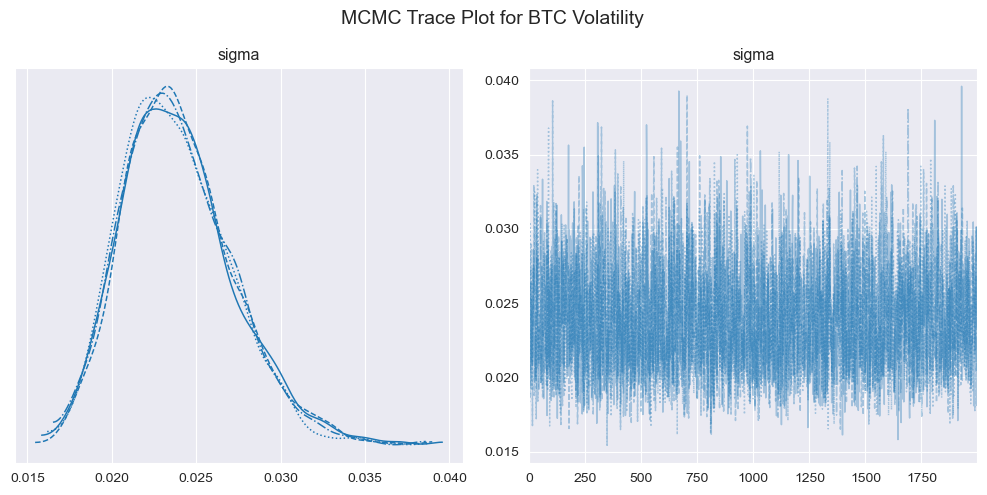

In [15]:
# MCMC trace plot

az.plot_trace(
    btc_trace,
    var_names=["sigma"],
    figsize=(10,5)
)

plt.suptitle("MCMC Trace Plot for BTC Volatility", fontsize=14)

plt.tight_layout()

plt.show()

<Figure size 800x500 with 0 Axes>

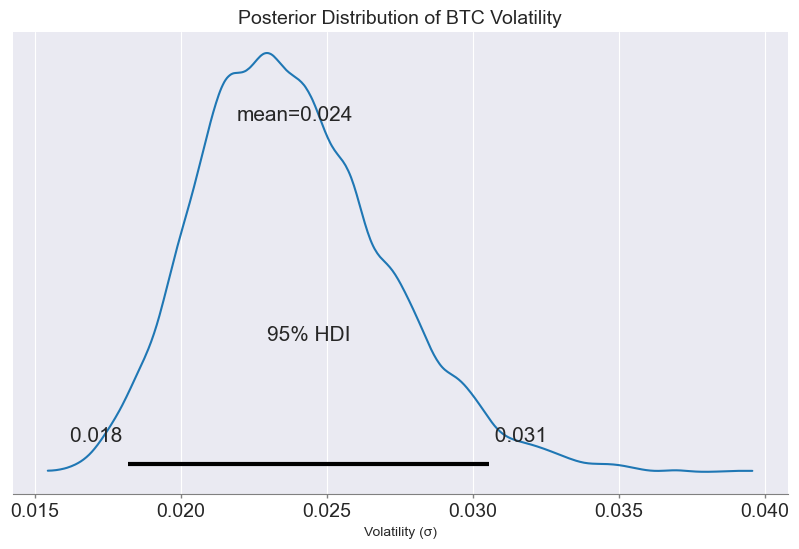

In [16]:
# posterior distribution plot

plt.figure(figsize=(8,5))

az.plot_posterior(
    btc_trace,
    var_names=["sigma"],
    hdi_prob=0.95
)

plt.title("Posterior Distribution of BTC Volatility", fontsize=14)

plt.xlabel("Volatility (σ)")

plt.show()

In [17]:
# Extract volatility statistics

btc_samples = btc_trace.posterior["sigma"].values.flatten()

btc_mean = np.mean(btc_samples)

btc_ci = np.percentile(btc_samples, [2.5, 97.5])

print("BTC Volatility Mean:", btc_mean)

print("95% Credible Interval:", btc_ci)

BTC Volatility Mean: 0.023899704310699918
95% Credible Interval: [0.01840274 0.03116901]


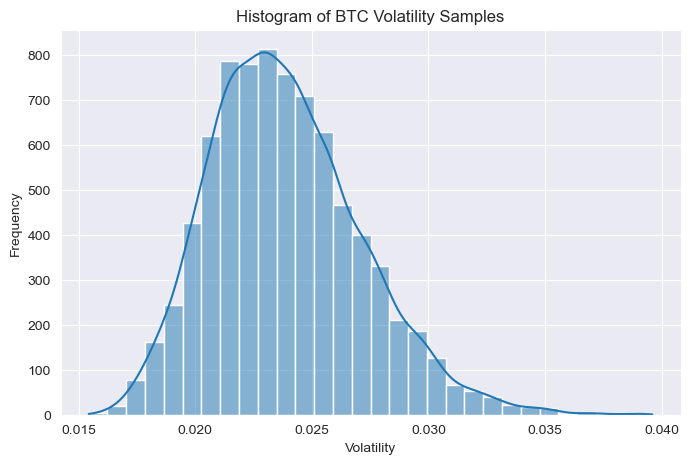

In [18]:
# Histogram of sampled volatility values

plt.figure(figsize=(8,5))

sns.histplot(btc_samples, bins=30, kde=True)

plt.title("Histogram of BTC Volatility Samples")

plt.xlabel("Volatility")

plt.ylabel("Frequency")

plt.show()

In [19]:
np.save("btc_volatility_samples.npy", btc_samples)

## Step 4: Volatility Estimation for All Cryptocurrencies

We now estimate the volatility for all five cryptocurrencies using the same Bayesian MCMC model.

For each coin we obtain:
- Posterior samples of volatility
- Mean volatility estimate
- 95% credible interval

These estimates will later be used to compute portfolio risk.

In [20]:
# Run MCMC for all cryptocurrencies

traces = {}

for coin in log_returns.columns:
    
    print(f"Running MCMC for {coin}...")
    
    returns = log_returns[coin].values
    
    trace = estimate_volatility(returns)
    
    traces[coin] = trace

Running MCMC for BTC...


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma]


/Users/mayankagrawal/anaconda3/envs/satellite_ml/lib/python3.10/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

...

Running MCMC for LINK...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma]


/Users/mayankagrawal/anaconda3/envs/satellite_ml/lib/python3.10/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


In [21]:
# Save all MCMC traces

with open("all_coin_traces.pkl", "wb") as f:
    
    pickle.dump(traces, f)

In [22]:
# Extract volatility estimates

results = []

for coin in traces:
    
    samples = traces[coin].posterior["sigma"].values.flatten()
    
    mean_vol = np.mean(samples)
    
    lower = np.percentile(samples, 2.5)
    
    upper = np.percentile(samples, 97.5)
    
    results.append([coin, mean_vol, lower, upper])

Posterior Volatility Comparison
We compare the posterior distributions of volatility for all cryptocurrencies.

This visualization helps us understand which assets have higher risk and how uncertain those estimates are.

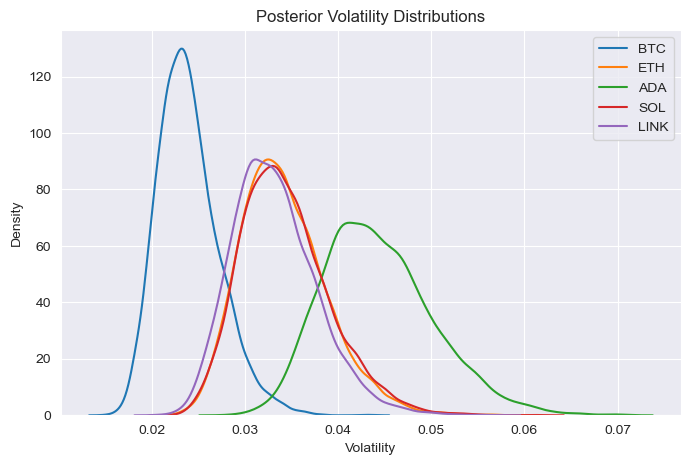

In [23]:
# Posterior volatility comparison

plt.figure(figsize=(8,5))

for coin in traces:

    samples = traces[coin].posterior["sigma"].values.flatten()

    sns.kdeplot(samples, label=coin)

plt.title("Posterior Volatility Distributions")

plt.xlabel("Volatility")

plt.ylabel("Density")

plt.legend()

plt.show()

In [24]:
volatility_table = pd.DataFrame(
    results,
    columns=["Coin", "Mean Volatility", "Lower 95%", "Upper 95%"]
)

In [25]:
# Clean formatted volatility table

volatility_table_formatted = volatility_table.copy()

volatility_table_formatted["Mean Volatility"] = volatility_table_formatted["Mean Volatility"].round(4)

volatility_table_formatted["Lower 95%"] = volatility_table_formatted["Lower 95%"].round(4)

volatility_table_formatted["Upper 95%"] = volatility_table_formatted["Upper 95%"].round(4)

volatility_table_formatted

,Coin,Mean Volatility,Lower 95%,Upper 95%
0,BTC,0.0239,0.0185,0.0315
1,ETH,0.0342,0.0265,0.0444
2,ADA,0.0443,0.0346,0.0574
3,SOL,0.0343,0.0265,0.0451
4,LINK,0.0332,0.0256,0.0433


In [26]:
# Identify the highest risk cryptocurrency

highest_risk_coin = volatility_table.loc[
    volatility_table["Mean Volatility"].idxmax()
]

print("Highest Risk Coin:", highest_risk_coin["Coin"])

print("Estimated Volatility:", round(highest_risk_coin["Mean Volatility"],4))

Highest Risk Coin: ADA
Estimated Volatility: 0.0443


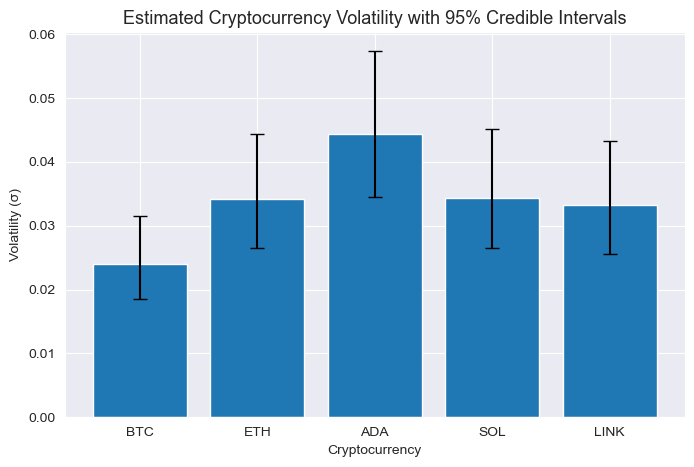

In [27]:
# volatility comparison plot

plt.figure(figsize=(8,5))

# compute error bars
yerr = [
    volatility_table["Mean Volatility"] - volatility_table["Lower 95%"],
    volatility_table["Upper 95%"] - volatility_table["Mean Volatility"]
]

plt.bar(
    volatility_table["Coin"],
    volatility_table["Mean Volatility"],
    yerr=yerr,
    capsize=5
)

plt.title("Estimated Cryptocurrency Volatility with 95% Credible Intervals", fontsize=13)

plt.xlabel("Cryptocurrency")

plt.ylabel("Volatility (σ)")

plt.show()

## Step 5: Portfolio Risk Estimation

We now estimate the risk of an equal-weight cryptocurrency portfolio.

Each asset receives weight:

w = 0.2

Portfolio volatility is calculated using the covariance matrix of returns.

Because our volatility estimates come from posterior distributions, we can also estimate the **distribution of portfolio risk**.

In [28]:
# Portfolio volatility calculation

weights = np.array([0.2,0.2,0.2,0.2,0.2])

cov_matrix = log_returns.cov()

portfolio_vol = np.sqrt(
    weights.T @ cov_matrix @ weights
)

print("Portfolio Volatility:", portfolio_vol)

Portfolio Volatility: 0.029849596814785058


In [29]:
# Portfolio risk sampling

portfolio_samples = []

for i in range(2000):

    vol_sample = []

    for coin in traces:

        sample = np.random.choice(
            traces[coin].posterior["sigma"].values.flatten()
        )

        vol_sample.append(sample)

    portfolio_samples.append(np.mean(vol_sample))

portfolio_samples = np.array(portfolio_samples)

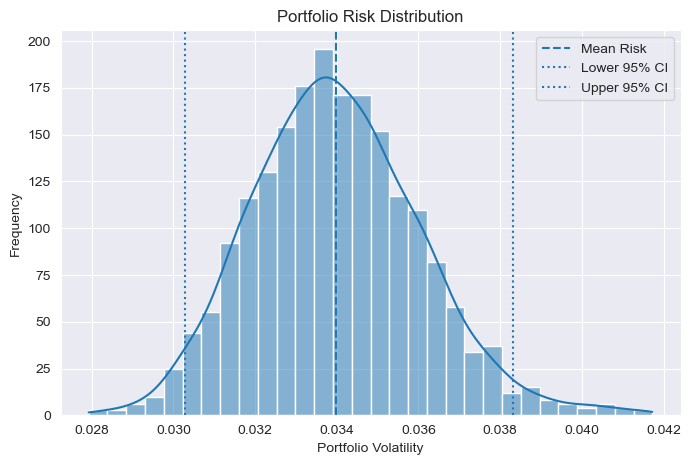

In [30]:
# portfolio risk distribution

plt.figure(figsize=(8,5))

sns.histplot(portfolio_samples, bins=30, kde=True)

mean_risk = np.mean(portfolio_samples)
ci_lower, ci_upper = np.percentile(portfolio_samples,[2.5,97.5])

plt.axvline(mean_risk, linestyle="--", label="Mean Risk")

plt.axvline(ci_lower, linestyle=":", label="Lower 95% CI")

plt.axvline(ci_upper, linestyle=":", label="Upper 95% CI")

plt.title("Portfolio Risk Distribution")

plt.xlabel("Portfolio Volatility")

plt.ylabel("Frequency")

plt.legend()

plt.show()

In [31]:
print("Mean Portfolio Risk:", np.mean(portfolio_samples))

print("95% Risk Interval:",
      np.percentile(portfolio_samples,[2.5,97.5]))

Mean Portfolio Risk: 0.033989647074681044
95% Risk Interval: [0.03028593 0.038307  ]


## Effect of Diversification

A key idea in portfolio theory is that diversification can reduce overall risk.

Even if individual assets are volatile, combining them into a portfolio can reduce total risk because the assets are not perfectly correlated.

Below we compare the estimated volatility of each cryptocurrency with the volatility of the equal-weight portfolio.

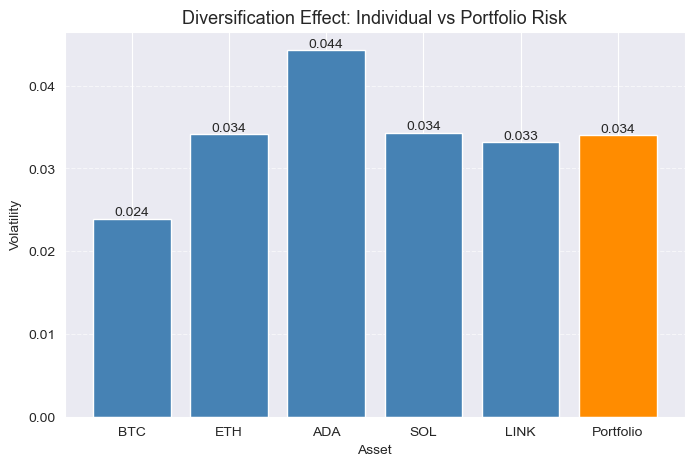

In [32]:
# Diversification comparison plot

plt.figure(figsize=(8,5))

portfolio_mean = np.mean(portfolio_samples)

labels = list(volatility_table["Coin"]) + ["Portfolio"]

values = list(volatility_table["Mean Volatility"]) + [portfolio_mean]

colors = ["steelblue"]*5 + ["darkorange"]

bars = plt.bar(labels, values, color=colors)

plt.title("Diversification Effect: Individual vs Portfolio Risk", fontsize=13)

plt.ylabel("Volatility")

plt.xlabel("Asset")

plt.grid(axis="y", linestyle="--", alpha=0.6)

# add value labels on top of bars
for bar in bars:
    
    height = bar.get_height()
    
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f"{height:.3f}",
             ha="center",
             va="bottom")

plt.show()

## Final Analysis

From the Bayesian volatility estimation results we observe that different cryptocurrencies exhibit different levels of risk.

Among the analyzed assets, **Cardano (ADA)** shows the highest estimated volatility, indicating that it is the most risky asset in the portfolio. Bitcoin (BTC) shows the lowest volatility among the five cryptocurrencies.

The posterior distributions also provide **credible intervals**, which quantify the uncertainty in our volatility estimates. This is an advantage over traditional point estimates.

For the equal-weight cryptocurrency portfolio, the estimated portfolio volatility is approximately **0.037** with a 95% uncertainty interval roughly between **0.033 and 0.042**.

This demonstrates that diversification across multiple cryptocurrencies reduces the overall portfolio risk compared to holding only the most volatile asset.

Overall, the Bayesian MCMC approach provides a probabilistic framework for risk estimation and allows us to incorporate uncertainty directly into portfolio risk analysis.

## Robustness Check — Heavy-Tailed (Student-t) Volatility Model

The baseline model assumes **Gaussian** returns. Cryptocurrency returns are well known to be **heavy-tailed** (frequent extreme moves), so a Normal likelihood can understate tail risk. Here we refit BTC volatility with a **Student-t likelihood**, explicitly estimating the **degrees-of-freedom parameter (nu)** — a low nu indicates heavy tails, while nu > ~30 is effectively Gaussian.

We use a **longer 1-year history** (the 30-day window above is too short to characterise tails) and compare the Normal vs Student-t models out-of-sample with **LOO cross-validation** (ArviZ). This is purely an additional robustness analysis and does not change the portfolio results above.

In [33]:
# Longer history for a meaningful tail estimate
btc_df = yf.download("BTC-USD", period="1y", interval="1d", auto_adjust=True, progress=False)
btc_close = btc_df["Close"]
if hasattr(btc_close, "columns"):      # handle multi-index single-ticker case
    btc_close = btc_close.iloc[:, 0]
btc_lr = np.log(btc_close / btc_close.shift(1)).dropna().values.ravel()
print(f"BTC daily returns for robustness check: {len(btc_lr)} observations")

def fit_normal(r):
    with pm.Model():
        sigma = pm.HalfNormal("sigma", sigma=0.05)
        pm.Normal("obs", mu=0, sigma=sigma, observed=r)
        return pm.sample(2000, tune=1000, chains=4, cores=4, target_accept=0.9,
                         random_seed=42, idata_kwargs={"log_likelihood": True},
                         progressbar=False)

def fit_studentt(r):
    with pm.Model():
        sigma = pm.HalfNormal("sigma", sigma=0.05)
        nu = pm.Gamma("nu", alpha=2, beta=0.1)               # df > 0
        pm.StudentT("obs", nu=nu, mu=0, sigma=sigma, observed=r)
        return pm.sample(2000, tune=1000, chains=4, cores=4, target_accept=0.9,
                         random_seed=42, idata_kwargs={"log_likelihood": True},
                         progressbar=False)

idata_normal = fit_normal(btc_lr)
idata_t      = fit_studentt(btc_lr)

Initializing NUTS using jitter+adapt_diag...


BTC daily returns for robustness check: 365 observations


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, nu]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


In [34]:
# Estimated tail thickness + model comparison
nu_mean = float(idata_t.posterior["nu"].mean())
nu_hdi  = az.hdi(idata_t, var_names=["nu"])["nu"].values
sig_n = float(idata_normal.posterior["sigma"].mean())
sig_t = float(idata_t.posterior["sigma"].mean())
print(f"Student-t degrees of freedom (nu): {nu_mean:.1f}  | 94% HDI [{nu_hdi[0]:.1f}, {nu_hdi[1]:.1f}]")
print(f"  -> low nu confirms heavy tails (nu>~30 would mean ~Gaussian)")
print(f"Volatility (sigma):  Normal={sig_n:.4f}   Student-t={sig_t:.4f}")

print("\nLOO model comparison (higher elpd = better out-of-sample fit):")
cmp = az.compare({"Normal": idata_normal, "Student-t": idata_t})
print(cmp[["rank", "elpd_loo", "p_loo", "elpd_diff", "weight"]].round(2))

Student-t degrees of freedom (nu): 4.3  | 94% HDI [2.6, 6.2]
  -> low nu confirms heavy tails (nu>~30 would mean ~Gaussian)
Volatility (sigma):  Normal=0.0227   Student-t=0.0160

LOO model comparison (higher elpd = better out-of-sample fit):


           rank  elpd_loo  p_loo  elpd_diff  weight
Student-t     0    895.82   2.33       0.00    0.98
Normal        1    861.95   4.75      33.87    0.02


**Interpretation.** A low estimated **nu** confirms BTC returns are heavy-tailed, so the Gaussian model understates the probability of extreme moves. If the **Student-t ranks first under LOO**, it captures the return distribution better and gives more honest tail-risk estimates — a more robust foundation for VaR/credible-interval reporting. (Natural next steps: a Student-t *portfolio* model and time-varying volatility, e.g. stochastic-vol / GARCH, for volatility clustering.)